# Section 5.5

## Example 5.5.3
$\sin(e^{x+1})$ at $x=0$

In [12]:
f(x) = sin(exp(x + 1))
exact_value = exp(1) * cos(exp(1))

-2.478349732955235

In [13]:
using PrettyTables

n = Int.(10 .^ (1:6))
h = 5 ./ n
FD = zeros(length(h), 2)
for (k, h) in enumerate(h)
    FD[k, 1] = (f(h) - f(0)) / h
    FD[k, 2] = (f(h) - f(-h)) / 2h
end
pretty_table([n h FD]; column_labels=["n", "h", "FD1", "FD2"], backend=:html)

n,h,FD1,FD2
10.0,0.5,-2.76858,-1.97047
100.0,0.05,-2.6128,-2.47552
1000.0,0.005,-2.49211,-2.47832
10000.0,0.0005,-2.47973,-2.47835
100000.0,5.0e-5,-2.47849,-2.47835
1.0e6,5.0e-6,-2.47836,-2.47835


In [14]:
error_FD = @. exact_value - FD
pretty_table([h error_FD]; 
    column_labels=["h", "error in FD1", "error in FD2"], backend=:html)

h,error in FD1,error in FD2
0.5,0.290226,-0.507878
0.05,0.134446,-0.00282948
0.005,0.0137555,-2.80378e-5
0.0005,0.00137813,-2.80353e-7
5.0e-5,0.000137838,-2.80297e-9
5.0e-6,1.37841e-5,1.53291e-11


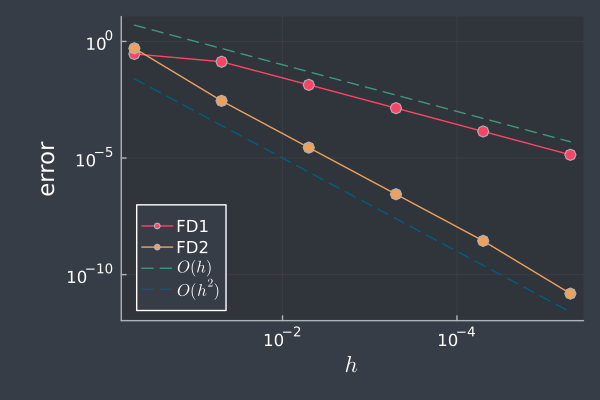

In [15]:
using Plots, LaTeXStrings
theme(:dark); default(thickness_scaling=1.4)

plot(h, abs.(error_FD); 
    m=:o,  label=["FD1" "FD2"], leg=:bottomleft,
    xflip=true,  xaxis=(:log10, L"h"),  yaxis=(:log10, "error"))

# Add lines for perfect 1st and 2nd order.
plot!(h, [10h 0.1h.^2], l=:dash, label=[L"O(h)" L"O(h^2)"])

## Example 5.5.4

In [16]:
using LinearAlgebra, PrettyTables

f(x) = exp(-1.3x)    
exact = -1.3         # f'(0)

h = [1 / 10^n for n in 1:12]
FD = zeros(length(h), 3)
for (k, h) in enumerate(h)
    nodes = h * (-2:2)
    vals = @. f(nodes)
    FD[k, 1] = dot([0, 0, -1, 1, 0] / h, vals)
    FD[k, 2] = dot([0, -1, 0, 1, 0] / 2h, vals)
    FD[k, 3] = dot([1, -8, 0, 8, -1] / 12h, vals)
end
pretty_table([h FD]; column_labels=["h", "FD1", "FD2", "FD4"], backend=:html)

h,FD1,FD2,FD4
0.1,-1.21905,-1.30366,-1.29999
0.01,-1.29159,-1.30004,-1.3
0.001,-1.29916,-1.3,-1.3
0.0001,-1.29992,-1.3,-1.3
1.0e-5,-1.29999,-1.3,-1.3
1.0e-6,-1.3,-1.3,-1.3
1.0e-7,-1.3,-1.3,-1.3
1.0e-8,-1.3,-1.3,-1.3
1.0e-9,-1.3,-1.3,-1.3
1.0e-10,-1.3,-1.3,-1.3


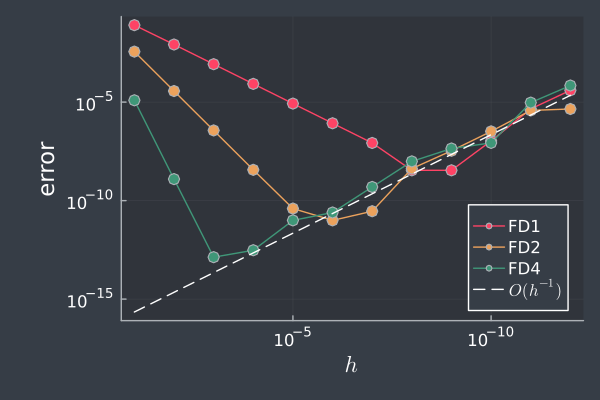

In [17]:
using Plots, LaTeXStrings
theme(:dark); default(thickness_scaling=1.4)

err = @. abs(FD - exact)

plot(h, err; m=:o, label=["FD1" "FD2" "FD4"],  legend=:bottomright,
    xaxis=(:log10, L"h"),  xflip=true,  yaxis=(:log10, "error"))

# Add line for perfect 1st order.
plot!(h, 0.1 * eps() ./ h, l=:dash, color=:white, label=L"O(h^{-1})")